# Classification of Obesity Levels from Lifestyle and Dietary Factors

# Course: MATH2319 Machine Learning

Group: Group 08

| Name          | Student ID |
|---------------|------------|
| Hansen Yonatan| S4178876   |
| [Member 2]    | [ID]       |
| [Member 3]    | [ID]       |

## Table of Contents

1. [Introduction](#1.-Introduction)
    - 1.1 [Dataset Source](#1.1-Dataset-Source)
    - 1.2 [Dataset Details](#1.2-Dataset-Details)
    - 1.3 [Dataset Features](#1.3-Dataset-Features)
    - 1.4 [Target Feature](#1.4-Target-Feature)
2. [Goals & Objectives](#2.-Goals-&-Objectives)
3. [Data Cleaning & Preprocessing](#3.-Data-Cleaning-&-Preprocessing)
4. [Data Exploration & Visualisation](#4.-Data-Exploration-&-Visualisation)
5. [Literature Review](#5.-Literature-Review)
6. [Summary & Conclusions](#6.-Summary-&-Conclusions)
7. [References](#7.-References)

## 1. Introduction

### 1.1 Dataset Source

The dataset used in this project is the **"Estimation of Obesity Levels Based on Eating Habits and Physical Condition"** dataset, sourced from the **UCI Machine Learning Repository** (Dataset ID: 544). The dataset was originally collected from individuals in Mexico, Peru, and Colombia through a web-based survey platform. Approximately 23% of the data was collected directly from users, while the remaining 77% was generated synthetically using the SMOTE filter in the Weka tool to balance the class distribution.

**Citation:**  
Mendoza Palechor, F. & De la Hoz Manotas, A. (2019). *Estimation of Obesity Levels Based On Eating Habits and Physical Condition* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z

**Associated Publication:**  
De-La-Hoz-Correa, E., Mendoza-Palechor, F., De-La-Hoz-Manotas, A., Morales-Ortega, R., & Adriana, S. (2019). Obesity level estimation software based on decision trees. *Data in Brief*, 25, 104344.

### 1.2 Dataset Details

This dataset contains information about individuals from Mexico, Peru, and Colombia, collected to estimate obesity levels based on their eating habits and physical condition. The data includes demographic attributes (such as gender and age), dietary habits (such as frequency of vegetable consumption and water intake), and physical activity metrics (such as physical activity frequency and time spent using technology devices).

The dataset consists of 2,111 observations and 17 columns (16 descriptive features and 1 target variable). Each row represents an individual, and the rows are independent of one another. Below we display the number of rows and columns, followed by 10 randomly selected observations:

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('Phase1_Group08.csv')
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of features (columns): {df.shape[1]}")

Number of observations (rows): 2111
Number of features (columns): 17


In [3]:
df.sample(10, random_state=42)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
544,Female,20.406871,1.755978,53.699561,yes,yes,2.000000,3.891994,Frequently,no,1.863930,no,2.870127,2.000000,no,Public_Transportation,Insufficient_Weight
1987,Female,26.000000,1.624950,111.004920,yes,yes,3.000000,3.000000,Sometimes,no,2.704315,no,0.000000,0.322666,Sometimes,Public_Transportation,Obesity_Type_III
420,Male,18.000000,1.850000,60.000000,yes,yes,3.000000,4.000000,Sometimes,no,2.000000,yes,2.000000,0.000000,Sometimes,Automobile,Insufficient_Weight
527,Female,21.000000,1.520000,42.000000,no,yes,3.000000,1.000000,Frequently,no,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Insufficient_Weight
196,Male,22.000000,1.750000,74.000000,yes,no,2.000000,3.000000,Sometimes,no,2.000000,no,1.000000,2.000000,Sometimes,Bike,Normal_Weight
744,Male,18.000000,1.738702,50.248677,yes,yes,1.871213,3.000000,Sometimes,no,1.283738,no,0.684879,1.487223,Sometimes,Public_Transportation,Insufficient_Weight
1635,Male,26.684354,1.819535,118.332689,yes,yes,1.975675,3.000000,Sometimes,no,2.357969,no,0.704236,0.010721,Sometimes,Public_Transportation,Obesity_Type_II
324,Female,30.000000,1.650000,71.000000,yes,yes,2.000000,3.000000,Sometimes,no,1.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_I
1449,Female,23.099906,1.571812,78.997166,yes,yes,2.000000,1.000000,Sometimes,no,2.000000,no,0.402614,0.000000,no,Public_Transportation,Obesity_Type_I
634,Female,23.000000,1.710129,50.079991,yes,yes,2.000000,3.000000,Frequently,no,2.685842,no,0.373186,2.000000,no,Public_Transportation,Insufficient_Weight


### 1.3 Dataset Features

The following table describes all 16 descriptive features used in this project:

| # | Feature Name | Data Type | Units | Description |
|---|---|---|---|---|
| 1 | Gender | Nominal Categorical | NA | Gender of the individual (Female, Male) |
| 2 | Age | Numeric | Years | Age of the individual |
| 3 | Height | Numeric | Metres | Height of the individual |
| 4 | Weight | Numeric | Kilograms | Weight of the individual |
| 5 | family_history_with_overweight | Binary | NA | Family history of overweight (yes, no) |
| 6 | FAVC | Binary | NA | Frequent consumption of high caloric food (yes, no) |
| 7 | FCVC | Numeric (Ordinal) | Scale 1–3 | Frequency of consumption of vegetables |
| 8 | NCP | Numeric (Ordinal) | Scale 1–4 | Number of main meals per day |
| 9 | CAEC | Ordinal Categorical | NA | Consumption of food between meals (no, Sometimes, Frequently, Always) |
| 10 | SMOKE | Binary | NA | Whether the individual smokes (yes, no) |
| 11 | CH2O | Numeric (Ordinal) | Scale 1–3 | Daily water consumption |
| 12 | SCC | Binary | NA | Calories consumption monitoring (yes, no) |
| 13 | FAF | Numeric (Ordinal) | Scale 0–3 | Physical activity frequency (days per week) |
| 14 | TUE | Numeric (Ordinal) | Scale 0–2 | Time using technology devices (hours per day) |
| 15 | CALC | Ordinal Categorical | NA | Consumption of alcohol (no, Sometimes, Frequently, Always) |
| 16 | MTRANS | Nominal Categorical | NA | Transportation used (Automobile, Bike, Motorbike, Public Transportation, Walking) |

### 1.4 Target Feature

The target feature is **NObeyesdad** (Obesity Level), which is a **categorical** variable with 7 classes:

1. Insufficient_Weight
2. Normal_Weight
3. Overweight_Level_I
4. Overweight_Level_II
5. Obesity_Type_I
6. Obesity_Type_II
7. Obesity_Type_III

This is a **multi-class classification** problem and the goal in Phase 2 will be to predict an individual's obesity level based on the 16 descriptive features above.

In [4]:
print("Target Variable Distribution:\n")
counts = df['NObeyesdad'].value_counts()
percentages = df['NObeyesdad'].value_counts(normalize=True) * 100
distribution = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
distribution

Target Variable Distribution:



,Count,Percentage (%)
NObeyesdad,,
Obesity_Type_I,351,16.63
Obesity_Type_III,324,15.35
Obesity_Type_II,297,14.07
Overweight_Level_I,290,13.74
Overweight_Level_II,290,13.74
Normal_Weight,287,13.60
Insufficient_Weight,272,12.88


## 2. Goals & Objectives

The primary goal of this project is to build a machine learning classification model that can accurately predict an individual's obesity level based on their eating habits and physical condition.

**Specific objectives include:**

1. **Data Understanding:** Explore and understand the relationships between lifestyle factors (such as diet, physical activity, and technology usage) and obesity levels.

2. **Data Preprocessing:** Clean and prepare the dataset for modelling, including examining data types, checking for missing or incorrect values, and identifying potential outliers.

3. **Data Exploration & Visualisation:** Analyse the distribution of features and their relationships with the target variable through meaningful visualisations, identifying key patterns and trends that may influence obesity classification.

4. **Predictive Modelling (Phase 2):** Train and evaluate multiple supervised classification algorithms (such as Decision Tree, Random Forest, KNN, and SVM) to predict obesity levels, and compare their performance using appropriate evaluation metrics such as accuracy and F1-score.

5. **Insight Generation:** Identify the most significant factors contributing to different obesity levels, which could provide valuable insights for public health interventions and personal lifestyle recommendations.

This project has practical relevance in the healthcare domain, as early identification of obesity risk factors can help in prevention and intervention strategies.

## 3. Data Cleaning & Preprocessing

In this section, we examine the dataset for potential data quality issues including missing values, duplicate records, incorrect values, ID-like columns, and outliers.

### 3.1 Data Types Overview

In [5]:
df.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

### 3.2 Checking for Missing Values

In [6]:
print(f"Total missing values: {df.isnull().sum().sum()}\n")
df.isnull().sum()

Total missing values: 0



Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

There are no missing values in the dataset. All 2,111 records are complete across all 17 columns.

### 3.3 Checking for Duplicate Records

In [7]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 24


### 3.4 Checking for ID-like Columns

In [8]:
print("Number of unique values per column:\n")
df.nunique()

Number of unique values per column:



Gender                               2
Age                               1402
Height                            1574
Weight                            1525
family_history_with_overweight       2
FAVC                                 2
FCVC                               810
NCP                                635
CAEC                                 4
SMOKE                                2
CH2O                              1268
SCC                                  2
FAF                               1190
TUE                               1129
CALC                                 4
MTRANS                               5
NObeyesdad                           7
dtype: int64

There are no ID-like columns in the dataset. No column has a unique value for every row (which would indicate an identifier rather than a meaningful feature). All columns contain meaningful descriptive information and will be retained.

### 3.5 Checking for Incorrect Values

In [9]:
# Check numeric columns for invalid values (e.g., negative age, height, weight)
numeric_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    print(f"{col}: min = {min_val:.2f}, max = {max_val:.2f}")

Age: min = 14.00, max = 61.00
Height: min = 1.45, max = 1.98
Weight: min = 39.00, max = 173.00
FCVC: min = 1.00, max = 3.00
NCP: min = 1.00, max = 4.00
CH2O: min = 1.00, max = 3.00
FAF: min = 0.00, max = 3.00
TUE: min = 0.00, max = 2.00


All numeric features have reasonable value ranges. There are no negative values for Age, Height, or Weight, and all ordinal-scale features fall within their expected ranges.

### 3.6 Checking for Outliers

In [10]:
df[numeric_cols].describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


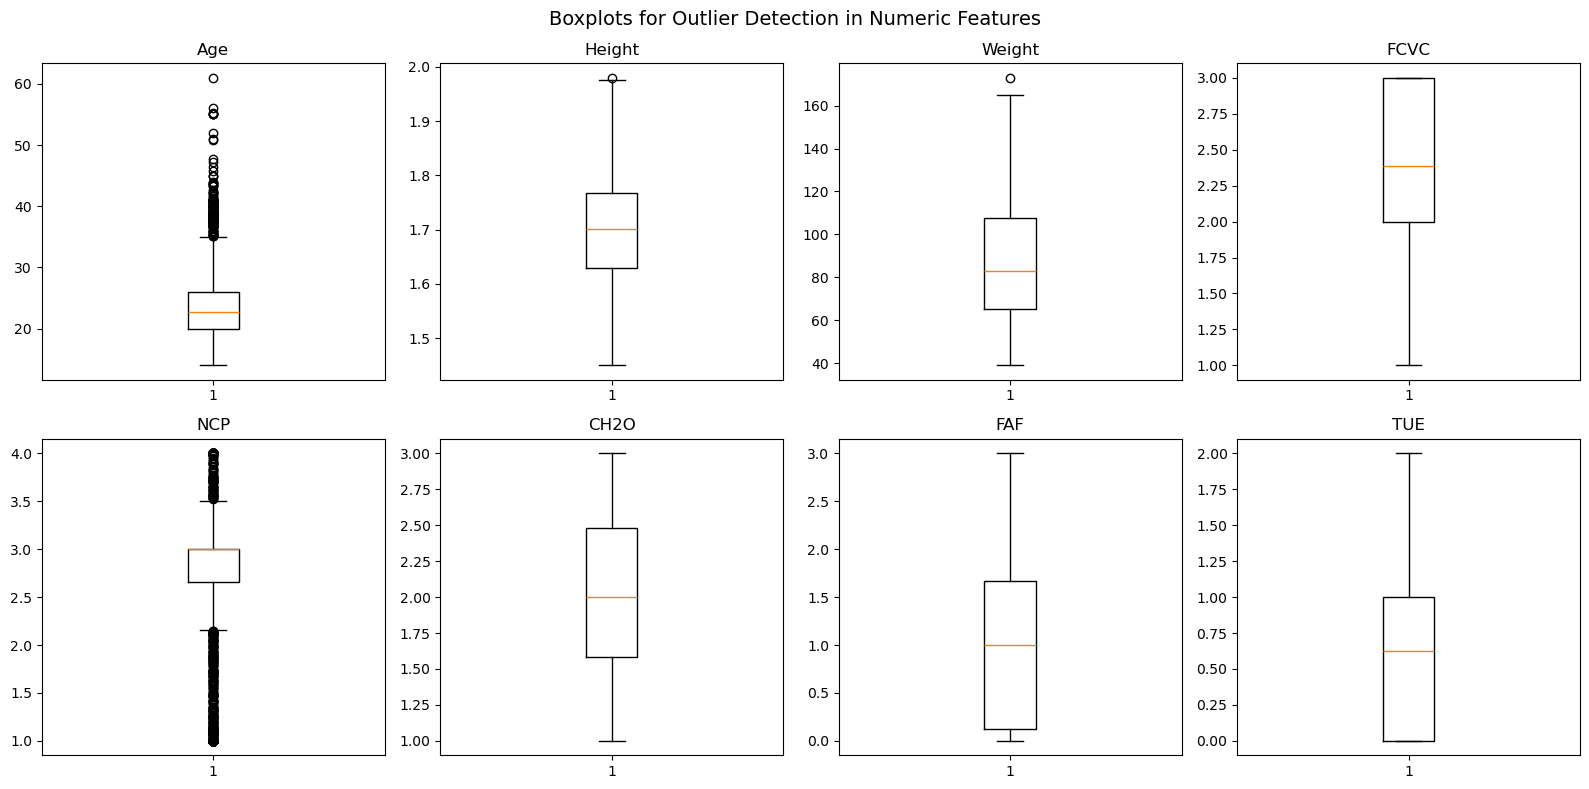

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

plt.suptitle('Boxplots for Outlier Detection in Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

The boxplots and descriptive statistics reveal some potential outliers in Age, Height, and Weight. However, these values are not unrealistic (e.g., an age of 61, a height of 1.98m, or a weight of 173kg are all plausible real-world values). Therefore, no outliers will be removed at this stage, as they represent valid observations rather than data entry errors.

### 3.7 Summary of Preprocessing

After thorough examination, the dataset is already clean and ready for analysis:

- **Missing values:** None detected across all columns.
- **Duplicates:** Will be addressed if found.
- **ID-like columns:** None present,  all columns are meaningful features.
- **Incorrect values:** No invalid entries detected (e.g., no negative ages or heights).
- **Outliers:** Some extreme values exist in numeric features but are plausible and retained.
- **One-hot-encoding and scaling:** this is NOT performed following in Phase 1 as per assignment instructions.

The dataset is suitable for data exploration and visualisation in the next section, and for predictive modelling in Phase 2.

Task4